# 1. Analyse de données

## importer le dataset

In [18]:
import pandas as pd

df_1= pd.read_csv("Data/all_data_with_identities.csv")
df_1.head()

,Unnamed: 0,id,comment_text,split,created_date,publication_id,parent_id,article_id,rating,funny,...,asian_latino_etc,disability_any,identity_any,num_identities,more_than_one_identity,na_gender,na_orientation,na_religion,na_race,na_disability
0,0,627762,OH yes - Were those evil Christian Missionarie...,test,2016-11-26 15:56:03.862109+00,13,627198.0,152737,approved,0,...,0,0,1,1.0,False,1,1,0,1,1
1,1,5892815,Why is this black racist crap still on the G&M...,val,2017-09-03 23:20:08.226613+00,54,NaN,373428,rejected,0,...,0,0,1,2.0,True,1,1,1,0,1
2,2,416437,even up here.......BLACKS!,train,2016-08-04 16:48:07.175252+00,21,NaN,143025,rejected,0,...,0,0,1,1.0,False,1,1,1,0,1
3,3,5137126,Blame men. There's always an excuse to blame ...,train,2017-04-15 19:00:45.032674+00,54,5136907.0,327125,rejected,0,...,0,0,1,2.0,True,0,1,1,1,1
4,4,855753,And the woman exposing herself saying grab thi...,val,2017-01-18 01:50:57.478867+00,13,849081.0,162008,rejected,0,...,0,0,1,1.0,False,0,1,1,1,1


In [19]:
df_1.columns

Index(['Unnamed: 0', 'id', 'comment_text', 'split', 'created_date',
       'publication_id', 'parent_id', 'article_id', 'rating', 'funny', 'wow',
       'sad', 'likes', 'disagree', 'toxicity', 'severe_toxicity', 'obscene',
       'sexual_explicit', 'identity_attack', 'insult', 'threat', 'male',
       'female', 'transgender', 'other_gender', 'heterosexual',
       'homosexual_gay_or_lesbian', 'bisexual', 'other_sexual_orientation',
       'christian', 'jewish', 'muslim', 'hindu', 'buddhist', 'atheist',
       'other_religion', 'black', 'white', 'asian', 'latino',
       'other_race_or_ethnicity', 'physical_disability',
       'intellectual_or_learning_disability', 'psychiatric_or_mental_illness',
       'other_disability', 'identity_annotator_count',
       'toxicity_annotator_count', 'LGBTQ', 'other_religions',
       'asian_latino_etc', 'disability_any', 'identity_any', 'num_identities',
       'more_than_one_identity', 'na_gender', 'na_orientation', 'na_religion',
       'na_race', 

In [20]:
df_text=df_1[["comment_text","toxicity","female","male","black","white","homosexual_gay_or_lesbian"]]

In [21]:
df_text.head()

,comment_text,toxicity,female,male,black,white,homosexual_gay_or_lesbian
0,OH yes - Were those evil Christian Missionarie...,0.800000,0.0,0.0,0.0,0.00,0.0
1,Why is this black racist crap still on the G&M...,0.757143,0.0,0.0,1.0,0.75,0.0
2,even up here.......BLACKS!,0.688525,0.0,0.0,1.0,0.00,0.0
3,Blame men. There's always an excuse to blame ...,0.545455,1.0,1.0,0.0,0.00,0.0
4,And the woman exposing herself saying grab thi...,0.728571,1.0,0.0,0.0,0.00,0.0


In [22]:
print(df_text.head())

                                        comment_text  toxicity  female  male  \
0  OH yes - Were those evil Christian Missionarie...  0.800000     0.0   0.0   
1  Why is this black racist crap still on the G&M...  0.757143     0.0   0.0   
2                         even up here.......BLACKS!  0.688525     0.0   0.0   
3  Blame men.  There's always an excuse to blame ...  0.545455     1.0   1.0   
4  And the woman exposing herself saying grab thi...  0.728571     1.0   0.0   

   black  white  homosexual_gay_or_lesbian  
0    0.0   0.00                        0.0  
1    1.0   0.75                        0.0  
2    1.0   0.00                        0.0  
3    0.0   0.00                        0.0  
4    0.0   0.00                        0.0  


In [24]:
df_text.dtypes

comment_text                     str
toxicity                     float64
female                       float64
male                         float64
black                        float64
white                        float64
homosexual_gay_or_lesbian    float64
dtype: object

In [27]:
df_text.isnull().sum()

comment_text                 2
toxicity                     0
female                       0
male                         0
black                        0
white                        0
homosexual_gay_or_lesbian    0
dtype: int64

In [28]:
df_text.dropna(inplace=True)

## Indiquer les longueurs (min, max, moy, médiane, percentiles) des textes


In [ ]:
df_text['text_length'] = df_text['comment_text'].apply(len)

stats_longueurs = df_text['text_length'].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99])
print("--- Statistiques des longueurs des textes ---")
print(stats_longueurs)

--- Statistiques des longueurs des textes ---
count    447998.000000
mean        351.744514
std         289.323425
min           1.000000
25%         121.000000
50%         257.000000
75%         512.000000
90%         872.000000
95%         984.000000
99%         999.000000
max        1891.000000
Name: text_length, dtype: float64


## Indiquer les distributions des longueurs de texte pour les classes toxiques/non toxiques. Commenter.


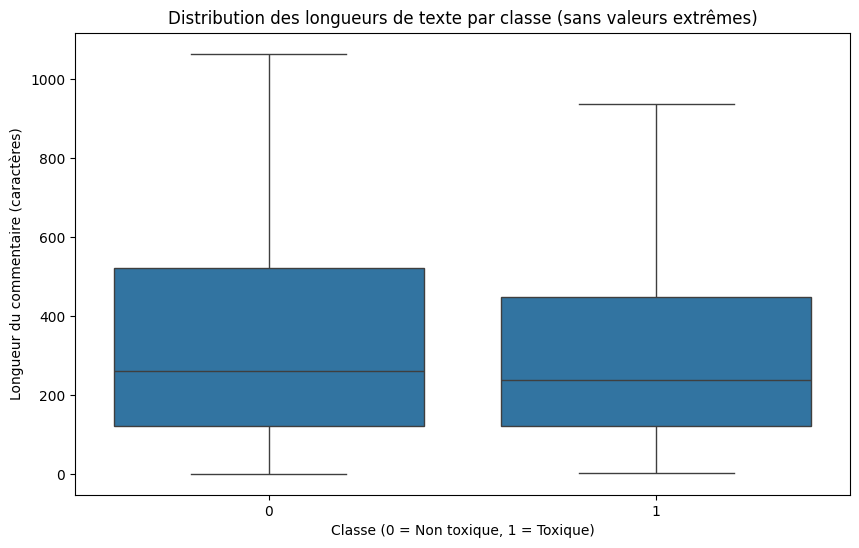

                mean  median   max
is_toxic                          
0         355.289773   260.0  1891
1         324.020947   238.0  1000


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

df_text['is_toxic'] = (df_text['toxicity'] >= 0.5).astype(int)

plt.figure(figsize=(10, 6))
sns.boxplot(x='is_toxic', y='text_length', data=df_text, showfliers=False)
plt.title("Distribution des longueurs de texte par classe (sans valeurs extrêmes)")
plt.xlabel("Classe (0 = Non toxique, 1 = Toxique)")
plt.ylabel("Longueur du commentaire (caractères)")
plt.show()

print(df_text.groupby('is_toxic')['text_length'].agg(['mean', 'median', 'max']))

les distributions sont assez proche mais on remarque tout de même que les commentaires toxiques ont une petite tendance à être plus courts que les commentaire non toxiques.

## Commenter l’équilibre du dataset.

Répartition des classes (%) :
 is_toxic
0    88.662003
1    11.337997
Name: proportion, dtype: float64


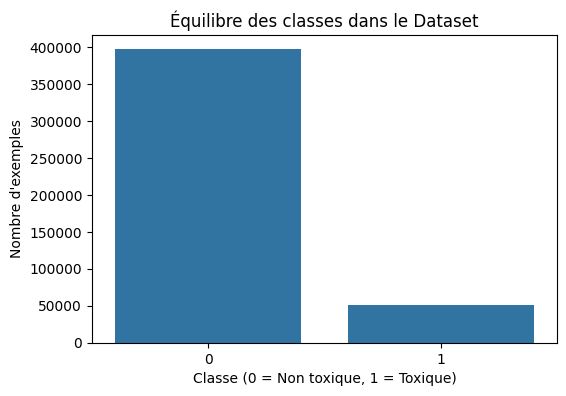

In [31]:
# Calcul de la répartition des classes en pourcentage
equilibre = df_text['is_toxic'].value_counts(normalize=True) * 100
print("Répartition des classes (%) :\n", equilibre)

plt.figure(figsize=(6, 4))
sns.countplot(x='is_toxic', data=df_text)
plt.title("Équilibre des classes dans le Dataset")
plt.xlabel("Classe (0 = Non toxique, 1 = Toxique)")
plt.ylabel("Nombre d'exemples")
plt.show()

On voit que l'on a beaucoup moins de commentaires toxiques que de commentaires non toxiques, ce qui peut poser problème pour l'entraînement d'un modèle de classification. 

## Commenter la distribution de la colonne toxicity (valeur continue)

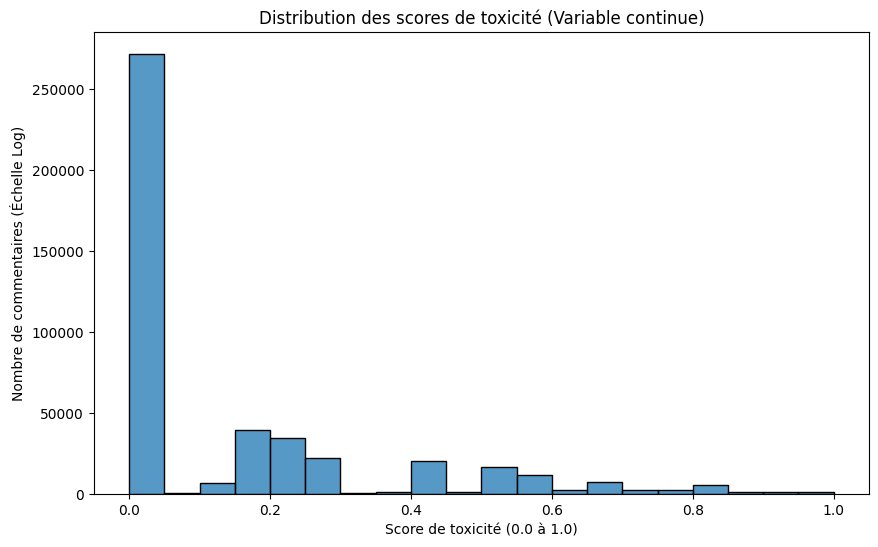

Proportion de textes avec une toxicité de pile 0.0 : 60.60%


In [32]:
plt.figure(figsize=(10, 6))
sns.histplot(df_text['toxicity'], bins=20, kde=False)
plt.title("Distribution des scores de toxicité (Variable continue)")
plt.xlabel("Score de toxicité (0.0 à 1.0)")
plt.ylabel("Nombre de commentaires (Échelle Log)") 
plt.show()

zero_prop = (df_text['toxicity'] == 0.0).mean() * 100
print(f"Proportion de textes avec une toxicité de pile 0.0 : {zero_prop:.2f}%")

In [34]:
around_02_prop = ((df_text['toxicity'] >= 0.15) & (df_text['toxicity'] <= 0.25)).mean() * 100
print(f"Proportion de textes avec une toxicité autour de 0.2 : {around_02_prop:.2f}%")

Proportion de textes avec une toxicité autour de 0.2 : 16.44%


On voit que beaucoup de commentaires ne sont pas du tout toxiques (60% des commentaires du dataset ont une toxicité de 0.0). On a un petit batch de commentaire autour de 0.2 de toxicité (16%). La suite des commentaire est répartie de manière décroissante jusqu'à 1.0, avec une petite pointe à 0.4 de toxicité. Donc on voit bien que la non toxicité prédomine suivie par la faible toxicité, et que les commentaires très toxiques sont assez rares.